In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

# ----------------------------
# File paths
# ----------------------------
pooled_volatility_path = r"..\..\..\notebooks\modelling\project_1_output\phase2_pooled_2022_2025\pooled_volatility_results.csv"
loto_volatility_path = r"..\..\..\notebooks\modelling\project_1_output\phase2_loto_2022_2025\loto_volatility_results.csv"

output_directory = r"..\..\..\notebooks\modelling\project_1_output\phase2_predictivity_celling_analysis"
# Create output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# ----------------------------
# Load
# ----------------------------
pooled_volatility_results = pd.read_csv(pooled_volatility_path)
loto_volatility_results = pd.read_csv(loto_volatility_path)

print("Pooled columns:")
print(pooled_volatility_results.columns.tolist())
print("\nLOTO columns:")
print(loto_volatility_results.columns.tolist())



Pooled columns:
['tmc', 'direction', 'tti_volatility', 'test_rows', 'mae_persistence', 'rmse_persistence', 'mae_pooled_xgb', 'rmse_pooled_xgb', 'mae_improvement_pooled_xgb', 'rmse_improvement_pooled_xgb']

LOTO columns:
['tmc', 'direction', 'tti_volatility', 'n_train', 'n_test', 'mae_persistence', 'rmse_persistence', 'mae_loto_xgb', 'rmse_loto_xgb', 'mae_improvement_loto_xgb', 'rmse_improvement_loto_xgb']


In [2]:
# Keep only needed columns
# -----------------------------
pooled_selected = pooled_volatility_results[
    [
        "tmc",
        "direction",
        "tti_volatility",
        "mae_persistence",
        "mae_pooled_xgb",
        "mae_improvement_pooled_xgb"
    ]
].copy()

loto_selected = loto_volatility_results[
    [
        "tmc",
        "direction",
        "tti_volatility",
        "mae_persistence",
        "mae_loto_xgb",
        "mae_improvement_loto_xgb"
    ]
].copy()

# Rename volatility and persistence in loto so merge is clean
loto_selected = loto_selected.rename(
    columns={
        "tti_volatility": "tti_volatility_loto",
        "mae_persistence": "mae_persistence_loto"
    }
)

# -----------------------------
# Merge pooled and loto results
# -----------------------------
segment_results_dataframe = pooled_selected.merge(
    loto_selected,
    on=["tmc", "direction"],
    how="inner"
)

# -----------------------------
# Use pooled volatility as the main one
# and check if volatility values match
# -----------------------------
segment_results_dataframe["volatility_difference"] = (
    segment_results_dataframe["tti_volatility"] - segment_results_dataframe["tti_volatility_loto"]
).abs()

print("Maximum difference between pooled and loto volatility values:",
      segment_results_dataframe["volatility_difference"].max())

print("Maximum difference between pooled and loto persistence MAE values:",
      (
          segment_results_dataframe["mae_persistence"] - segment_results_dataframe["mae_persistence_loto"]
      ).abs().max())

# If they match, keep one version
segment_results_dataframe = segment_results_dataframe.drop(
    columns=["tti_volatility_loto", "mae_persistence_loto", "volatility_difference"]
)

segment_results_dataframe.head()

Maximum difference between pooled and loto volatility values: 0.0
Maximum difference between pooled and loto persistence MAE values: 0.0


,tmc,direction,tti_volatility,mae_persistence,mae_pooled_xgb,mae_improvement_pooled_xgb,mae_loto_xgb,mae_improvement_loto_xgb
0,110+04164,WESTBOUND,0.657274,0.073712,0.068843,0.004868,0.074124,-0.000412
1,110+04165,WESTBOUND,0.263098,0.092874,0.080560,0.012314,0.089138,0.003736
2,110+04166,WESTBOUND,0.465832,0.194072,0.164842,0.029230,0.172253,0.021819
3,110+04167,WESTBOUND,0.389231,0.233482,0.206909,0.026573,0.217103,0.016379
4,110+04168,WESTBOUND,0.615829,0.214558,0.192557,0.022001,0.198634,0.015924


In [3]:
def fit_volatility_error_model(dataframe, outcome_column_name, volatility_column_name="tti_volatility"):
    model_dataframe = dataframe[[volatility_column_name, outcome_column_name]].dropna().copy()

    X = sm.add_constant(model_dataframe[volatility_column_name])
    y = model_dataframe[outcome_column_name]

    fitted_model = sm.OLS(y, X).fit()

    model_summary_row = {
        "outcome": outcome_column_name,
        "number_of_segments": len(model_dataframe),
        "intercept": fitted_model.params["const"],
        "slope": fitted_model.params[volatility_column_name],
        "r_squared": fitted_model.rsquared,
        "adjusted_r_squared": fitted_model.rsquared_adj,
        "p_value_for_slope": fitted_model.pvalues[volatility_column_name]
    }

    return fitted_model, model_summary_row

In [4]:
persistence_model, persistence_summary = fit_volatility_error_model(
    segment_results_dataframe,
    "mae_persistence"
)

pooled_model, pooled_summary = fit_volatility_error_model(
    segment_results_dataframe,
    "mae_pooled_xgb"
)

loto_model, loto_summary = fit_volatility_error_model(
    segment_results_dataframe,
    "mae_loto_xgb"
)

predictability_ceiling_results = pd.DataFrame(
    [persistence_summary, pooled_summary, loto_summary]
)

predictability_ceiling_results

,outcome,number_of_segments,intercept,slope,r_squared,adjusted_r_squared,p_value_for_slope
0,mae_persistence,41,0.012303,0.309250,0.605377,0.595259,2.145358e-09
1,mae_pooled_xgb,41,0.009632,0.281162,0.623512,0.613859,8.455878e-10
2,mae_loto_xgb,41,0.015736,0.289803,0.599355,0.589082,2.895812e-09


In [5]:
predictability_ceiling_results_for_paper = predictability_ceiling_results.copy()

predictability_ceiling_results_for_paper["intercept"] = (
    predictability_ceiling_results_for_paper["intercept"].round(4)
)
predictability_ceiling_results_for_paper["slope"] = (
    predictability_ceiling_results_for_paper["slope"].round(4)
)
predictability_ceiling_results_for_paper["r_squared"] = (
    predictability_ceiling_results_for_paper["r_squared"].round(3)
)
predictability_ceiling_results_for_paper["adjusted_r_squared"] = (
    predictability_ceiling_results_for_paper["adjusted_r_squared"].round(3)
)
predictability_ceiling_results_for_paper["p_value_for_slope"] = (
    predictability_ceiling_results_for_paper["p_value_for_slope"].apply(lambda x: f"{x:.2e}")
)
predictability_ceiling_results_for_paper.to_csv(
    os.path.join(output_directory, "predictability_ceiling_regression_results.csv"),
    index=False
)
predictability_ceiling_results_for_paper

,outcome,number_of_segments,intercept,slope,r_squared,adjusted_r_squared,p_value_for_slope
0,mae_persistence,41,0.0123,0.3093,0.605,0.595,2.15e-09
1,mae_pooled_xgb,41,0.0096,0.2812,0.624,0.614,8.46e-10
2,mae_loto_xgb,41,0.0157,0.2898,0.599,0.589,2.90e-09


In [6]:
def plot_volatility_vs_error_with_fitted_line(
    dataframe,
    outcome_column_name,
    plot_title,
    y_axis_label,
    filename,
    volatility_column_name="tti_volatility"
):
    plot_dataframe = dataframe[[volatility_column_name, outcome_column_name]].dropna().copy()

    X = sm.add_constant(plot_dataframe[volatility_column_name])
    y = plot_dataframe[outcome_column_name]

    fitted_model = sm.OLS(y, X).fit()

    x_values = plot_dataframe[volatility_column_name].to_numpy()
    y_values = plot_dataframe[outcome_column_name].to_numpy()

    x_line = np.linspace(x_values.min(), x_values.max(), 200)
    X_line = sm.add_constant(x_line)
    y_line = fitted_model.predict(X_line)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_values, y_values)
    plt.plot(x_line, y_line)

    plt.xlabel("TTI Volatility (training period standard deviation)")
    plt.ylabel(y_axis_label)
    plt.title(plot_title)
    plt.grid(True)

    plt.savefig(os.path.join(output_directory, f"{filename}"), dpi=300, bbox_inches="tight")
    plt.show()

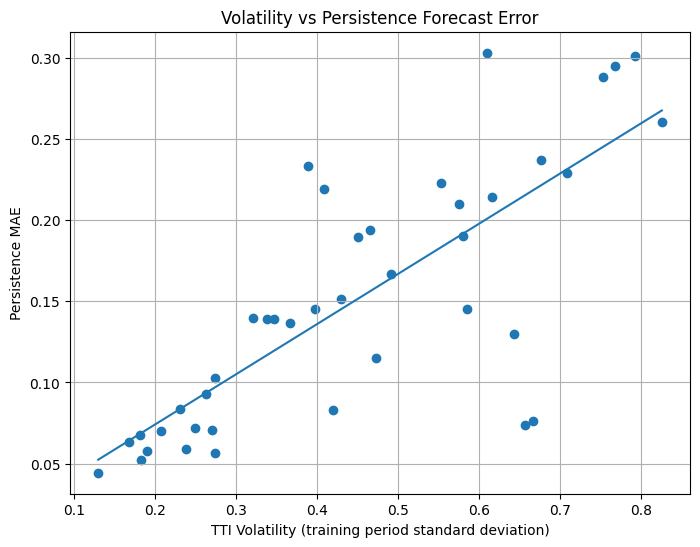

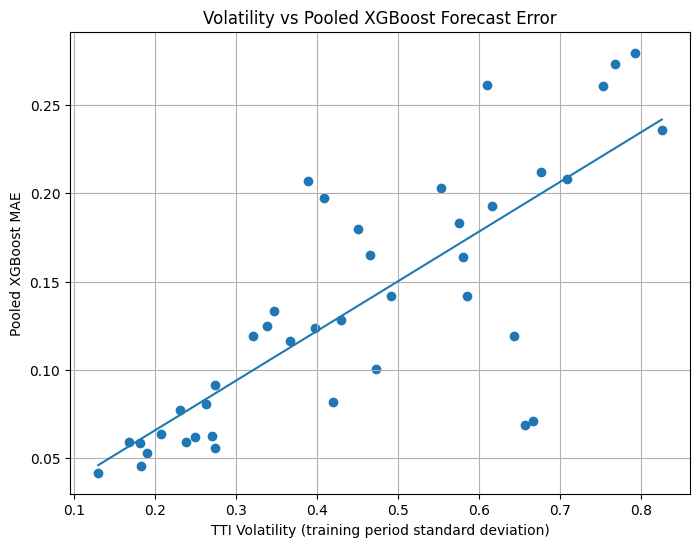

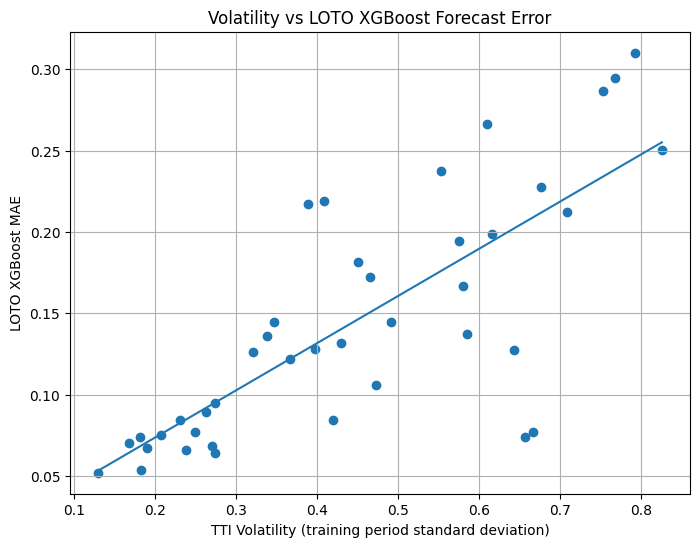

In [7]:
plot_volatility_vs_error_with_fitted_line(
    segment_results_dataframe,
    "mae_persistence",
    "Volatility vs Persistence Forecast Error",
    "Persistence MAE",
    "figure_volatility_vs_persistence_error.png"
)

plot_volatility_vs_error_with_fitted_line(
    segment_results_dataframe,
    "mae_pooled_xgb",
    "Volatility vs Pooled XGBoost Forecast Error",
    "Pooled XGBoost MAE",
    "figure_volatility_vs_pooled_xgb_error.png"
)

plot_volatility_vs_error_with_fitted_line(
    segment_results_dataframe,
    "mae_loto_xgb",
    "Volatility vs LOTO XGBoost Forecast Error",
    "LOTO XGBoost MAE",
    "figure_volatility_vs_loto_xgb_error.png"
)

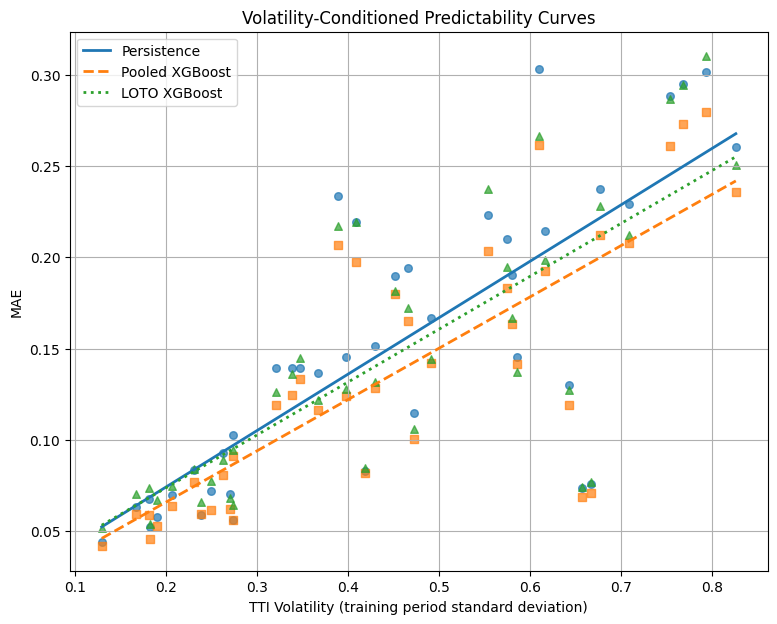

In [10]:
def plot_all_predictability_lines_together(dataframe):

    plt.figure(figsize=(9,7))

    model_configurations = [
        ("mae_persistence", "Persistence", "o", "-"),
        ("mae_pooled_xgb", "Pooled XGBoost", "s", "--"),
        ("mae_loto_xgb", "LOTO XGBoost", "^", ":")
    ]

    for outcome_column_name, label_name, marker_style, line_style in model_configurations:

        plot_dataframe = dataframe[["tti_volatility", outcome_column_name]].dropna()

        X = sm.add_constant(plot_dataframe["tti_volatility"])
        y = plot_dataframe[outcome_column_name]

        fitted_model = sm.OLS(y, X).fit()

        x_line = np.linspace(
            plot_dataframe["tti_volatility"].min(),
            plot_dataframe["tti_volatility"].max(),
            200
        )

        X_line = sm.add_constant(x_line)
        y_line = fitted_model.predict(X_line)

        # scatter points
        plt.scatter(
            plot_dataframe["tti_volatility"],
            plot_dataframe[outcome_column_name],
            marker=marker_style,
            s=30,
            alpha=0.7
        )

        # fitted line
        plt.plot(
            x_line,
            y_line,
            linestyle=line_style,
            linewidth=2,
            label=label_name
        )

    plt.xlabel("TTI Volatility (training period standard deviation)")
    plt.ylabel("MAE")
    plt.title("Volatility-Conditioned Predictability Curves")

    plt.legend()
    plt.grid(True)
    plt.savefig(
        os.path.join(output_directory, "figure_predictability_ceiling_models.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

plot_all_predictability_lines_together(segment_results_dataframe)

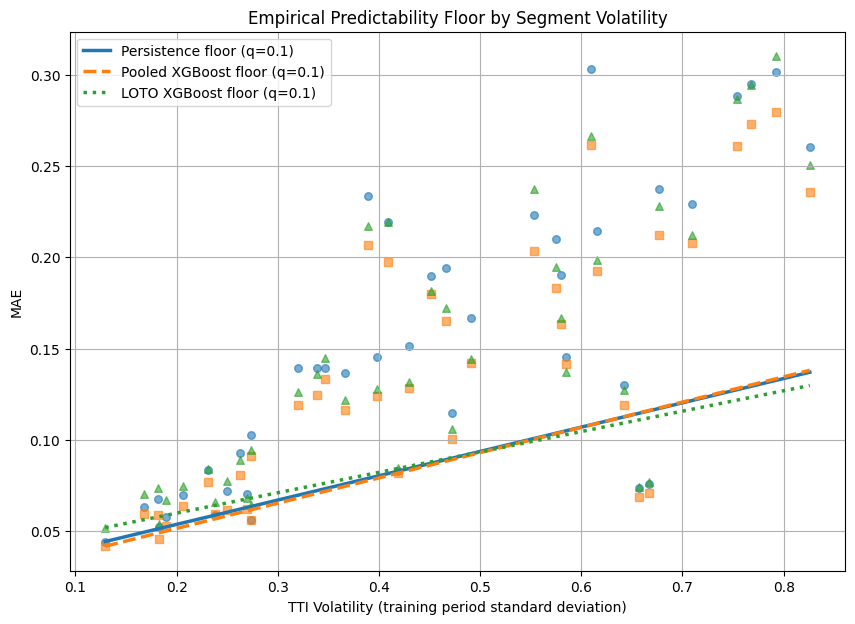

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


def fit_quantile_predictability_floor(dataframe, outcome_column_name, quantile_level=0.10):
    plot_dataframe = dataframe[["tti_volatility", outcome_column_name]].dropna().copy()

    X = sm.add_constant(plot_dataframe["tti_volatility"])
    y = plot_dataframe[outcome_column_name]

    quantile_model = sm.QuantReg(y, X).fit(q=quantile_level)

    return quantile_model


def plot_predictability_floor_curves(dataframe, quantile_level=0.10):
    plt.figure(figsize=(10, 7))

    model_configurations = [
        ("mae_persistence", "Persistence", "o", "-"),
        ("mae_pooled_xgb", "Pooled XGBoost", "s", "--"),
        ("mae_loto_xgb", "LOTO XGBoost", "^", ":")
    ]

    for outcome_column_name, label_name, marker_style, line_style in model_configurations:
        plot_dataframe = dataframe[["tti_volatility", outcome_column_name]].dropna().copy()

        x_values = plot_dataframe["tti_volatility"].to_numpy()
        y_values = plot_dataframe[outcome_column_name].to_numpy()

        quantile_model = fit_quantile_predictability_floor(
            dataframe,
            outcome_column_name,
            quantile_level=quantile_level
        )

        x_line = np.linspace(x_values.min(), x_values.max(), 200)
        X_line = sm.add_constant(x_line)
        y_floor = quantile_model.predict(X_line)

        plt.scatter(
            x_values,
            y_values,
            marker=marker_style,
            s=30,
            alpha=0.6
        )

        plt.plot(
            x_line,
            y_floor,
            linestyle=line_style,
            linewidth=2.5,
            label=f"{label_name} floor (q={quantile_level})"
        )

    plt.xlabel("TTI Volatility (training period standard deviation)")
    plt.ylabel("MAE")
    plt.title("Empirical Predictability Floor by Segment Volatility")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        os.path.join(output_directory, "figure_predictability_floor_quantile.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

plot_predictability_floor_curves(segment_results_dataframe, quantile_level=0.10)